In [1]:
import json
import os 
import torch

from mil.builder import create_model, save_model, create_aggregator
from mil.losses import LOSS_DICT
from mil.train.utils import (
    visualize_errors, 
    print_metrics,
    print_label_metrics, 
    specificity_precision_recall_f1_auc_acc,
    entropy_based_fusion,
    entropy_weights_from_logits
)
from pathlib import Path
import argparse

/root/userfolder/anaconda3/envs/mil/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/root/userfolder/anaconda3/envs/mil/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/root/userfolder/anaconda3/envs/mil/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The '

## 加载 Dataset

In [2]:
from mil.data.vlmil_dataset import DualModalNeonatalFundusDataset
valid_path = "/root/userfolder/data-ckpts/VL-MIL/datasets/v2/screenings/nfi_valid.json"
train_path = "/root/userfolder/data-ckpts/VL-MIL/datasets/v2/screenings/nfi_train.json"
# dataset = NeonatalFundusDataset(valid_path, feature_type='qwen', tokens='image', layer=3)
# dataset = DualModalNeonatalFundusDataset([train_path, valid_path], tokens='image', layer=23)
dataset = DualModalNeonatalFundusDataset([valid_path], tokens='image', layer=23)

[Dataset] Loading dataset from /root/userfolder/data-ckpts/VL-MIL/datasets/v2/screenings/nfi_valid.json
[Dataset] Successfully loaded 1851 samples from /root/userfolder/data-ckpts/VL-MIL/datasets/v2/screenings/nfi_valid.json


In [3]:
for key, value in dataset[0].items():
    if isinstance(value, torch.Tensor):
        print(key, value.shape)
    else:
        print(key, value)

id 8
num_image 18
patient an_ziling_1702527_20171026
label 0
input_features torch.Size([18, 729, 3584])
output_features torch.Size([18, 28, 3584])


In [4]:
from mil.data.data_components import last_token

# sample = dataset[1700]
# image_features = sample['input_features'].float()
# text_features = last_token(sample['output_features']).float()
# labels = torch.tensor([sample['label']]).long()
# masks = None 

# labels


In [9]:
import torch.nn as nn 
from typing import Optional
from mil.constants import ENCODER_DIM_MAPPING 

class GVLMIL(nn.Module):
    def __init__(self, config=None, ckpt_path=None):
        super().__init__()
        # load from checkpoint
        if ckpt_path is not None:
            print("Load GVL-MIL")
            with open(os.path.join(ckpt_path, 'training_args.json'), 'r') as f:
                config_json = json.load(f)
            self.config = argparse.Namespace(**config_json)
        else:
            print("Create GVL-MIL")
            self.config = config
        
        # print(self.config.loss)
        if ckpt_path is not None:
            directory = Path(ckpt_path)
            # 只返回直接子目录名
            folders = [item.name for item in directory.iterdir() if item.is_dir()]
            if len(folders) > 0:
                weight_path = folders[0]
            self.loss_fn = LOSS_DICT[self.config.loss]
            img_mil_path = os.path.join(ckpt_path, weight_path, 'image_mil', 'model.safetensors')
            text_mil_path = os.path.join(ckpt_path, weight_path, 'text_mil', 'model.safetensors')
            agg_path = os.path.join(ckpt_path, weight_path, 'aggregator.pth')
            from_pretrained = True
        else:
            img_mil_path, text_mil_path, agg_path = "", "", ""
            self.loss_fn = nn.CrossEntropyLoss()
            from_pretrained = False

        # load checkpoints
        self.aggregator = create_aggregator('xattn', self.config.encoder)
        if os.path.isfile(agg_path) and agg_path.endswith('.pth'):
            agg_ckpt = torch.load(agg_path)
            self.aggregator.load_state_dict(agg_ckpt)

        # load dual-branch mil
        mil_name = ".".join([self.config.mil_name, self.config.cfg_name, self.config.encoder])
        self.image_mil = create_model(
            mil_name, num_classes=self.config.num_labels, 
            checkpoint_path=img_mil_path, 
            from_pretrained=from_pretrained,
            keep_classifier=True
            )
        self.text_mil = create_model(
            mil_name, num_classes=self.config.num_labels, 
            checkpoint_path=text_mil_path, 
            from_pretrained=from_pretrained, 
            keep_classifier=True)
        
    def forward(
            self, 
            image_features: torch.Tensor, 
            text_features: torch.Tensor, 
            labels: torch.LongTensor, 
            masks: Optional[torch.Tensor] = None, 
            visualize: Optional[bool] = False
        ):
        assert image_features.shape[-1] == ENCODER_DIM_MAPPING[self.config.encoder]
        assert text_features.shape[-1] == ENCODER_DIM_MAPPING[self.config.encoder]
        if image_features.ndim == 3:
            image_features = image_features.unsqueeze(0)
        if text_features.ndim == 2:
            text_features = text_features.unsqueeze(0)

        # print(image_features.shape, text_features.shape)

        # an image is represented by a feature map rather than a vector
        if image_features.ndim == 4:
            # todo: add aggregator
            if image_features.shape[-2] > 1:
                if self.aggregator is not None:
                    image_features = self.aggregator(image_features, instance_mask=masks)
                else:
                    image_features = image_features[:,:,-1,:]
            elif image_features.shape[-2] == 1:
                image_features = image_features.squeeze(-2)
        
        # print(image_features.shape, text_features.shape)
        # print(labels.shape)
        
        if self.config.fusion != 'feature':
            outputs1 = self.image_mil(image_features, self.loss_fn, labels, masks)
            outputs2 = self.text_mil(text_features, self.loss_fn, labels, masks)
            logits1, logits2 = outputs1[0]['logits'], outputs2[0]['logits']
            loss = outputs1[0]['loss'] + outputs2[0]['loss']
            weights = entropy_weights_from_logits([logits1, logits2])
            w1 = weights[:, 0].unsqueeze(-1)  # (B, 1)
            w2 = weights[:, 1].unsqueeze(-1)  # (B, 1)
            logits = logits1 * w1 + logits2 * w2 

        outputs = {"logits": logits, "loss": loss}
        if visualize:
            outputs['weights'] = {'image': w1, "text": w2}


        return outputs
    
ckpt_path = "/root/userfolder/data-ckpts/VL-MIL/checkpoints/v2/mil_weights/main_ours/dsmil-0"
model = GVLMIL(ckpt_path=ckpt_path)

/root/userfolder/MIL/VL-MIL/mil/builder/ModelDict.py:193: UserWarning: Pretrained flag is True, but task is set to 'none'. Using random weights
  warnings.warn("Pretrained flag is True, but task is set to 'none'. Using random weights")
2025-11-19 16:57:22.602 | WARNING  | mil.builder:_update_checkpoint_path:107 - Checkpoint path manually provided (/root/userfolder/data-ckpts/VL-MIL/checkpoints/v2/mil_weights/main_ours/dsmil-0/15Epoch/image_mil/model.safetensors). Overwriting previous local filepath /root/userfolder/data-ckpts/VL-MIL/checkpoints/v2/mil_weights/dsmil.base.qwen2-7b.none.
2025-11-19 16:57:22.630 | INFO     | mil.builder.builder_utils:load_pretrained:316 - Loading pretrained weights from file (/root/userfolder/data-ckpts/VL-MIL/checkpoints/v2/mil_weights/main_ours/dsmil-0/15Epoch/image_mil/model.safetensors)
2025-11-19 16:57:22.632 | INFO     | mil.builder.builder_utils:load_state_dict:136 - Loaded  from checkpoint '/root/userfolder/data-ckpts/VL-MIL/checkpoints/v2/mil_weig

Load GVL-MIL
"Model name dsmil.base.qwen2-7b does not have a task, using default task none.
"Model name dsmil.base.qwen2-7b does not have a task, using default task none.


In [10]:
assert False

AssertionError: 

### 统计在整个验证集上 W_I 和 W_T 的分布

In [59]:
from tqdm import tqdm 
model.eval()
model.cuda()
image_weights = []
text_weights = []

with torch.inference_mode():
    for sample in tqdm(dataset):
        # sample = dataset[1700]
        image_features = sample['input_features'].float().cuda()
        text_features = last_token(sample['output_features']).float().cuda()
        labels = torch.tensor([sample['label']]).long().cuda()
        max_K = text_features.shape[0]
        arange_K = torch.arange(max_K).unsqueeze(0)
        masks = (arange_K < max_K).float()
        # print(labels, torch.argmax(model(image_features, text_features, labels, masks)[0], dim=1))
        # print(labels, model(image_features, text_features, labels, masks))
        outputs = model(image_features, text_features, labels, masks, visualize=True)
        # print(outputs['weights'])
        image_weights.append(outputs['weights']['image'])
        text_weights.append(outputs['weights']['text'])

  4%|▍         | 82/1851 [00:38<29:56,  1.02s/it]

### 对于单个样本进行可视化

In [ ]:
import numpy as np
# image_weights, text_weights
np_image_weights = np.array(image_weights)
np_text_weights = np.array(text_weights)

np_image_weights.mean(), np_text_weights.mean()

(0.56004286, 0.43995717)

In [ ]:
labels = [sample['label'] for sample in dataset]

In [ ]:
labels.index(1), labels.index(2), labels.index(3)
image_weights_4 = []
text_weights_4 = []

for i in range(4):
    lpos = labels.index(i)
    rpos = labels.index(i+1) if (i+1) in labels else len(labels)
    image_weights_4.append(float(sum(image_weights[lpos:rpos]) / (rpos-lpos)))
    text_weights_4.append(float(sum(text_weights[lpos:rpos]) / (rpos-lpos)))
    
image_weights_4, text_weights_4

([0.001451378809869376, 0.0, 0.0, 0.0], [0.001451378809869376, 0.0, 0.0, 0.0])

Saved figure to: modality_comparison_simple.png


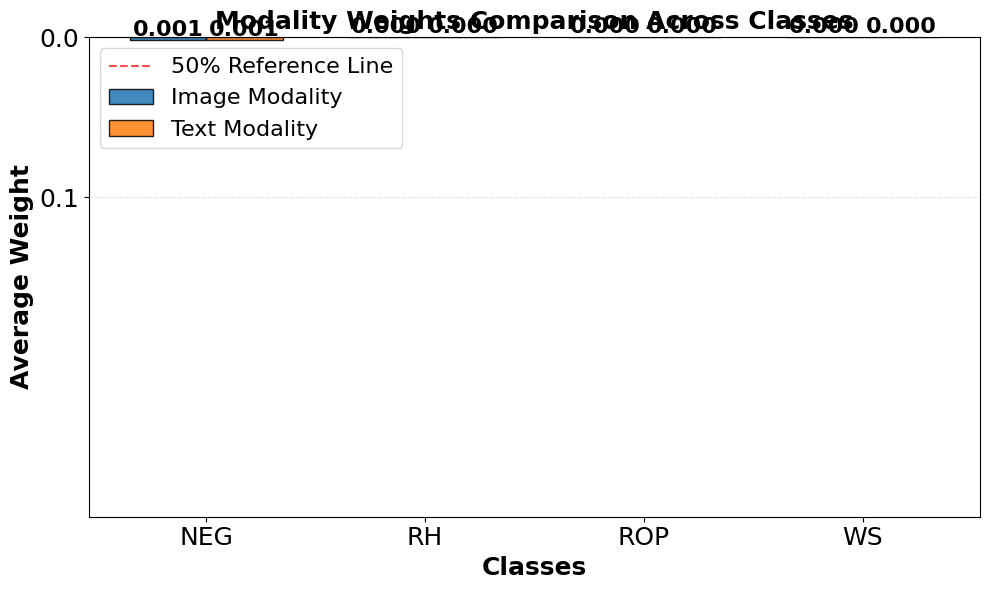


=== Modality Weights Summary ===
NEG:
  Image: 0.001 (50.0%)
  Text:  0.001 (50.0%)
  Diff:  +0.000



ZeroDivisionError: float division by zero

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False


def add_value_labels(ax, bars, fontsize=14):
    """在柱状图顶部添加数值标签"""
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=fontsize,
            fontweight="bold"
        )


def print_summary(class_names, image_means, text_means):
    """打印统计摘要"""
    print("\n=== Modality Weights Summary ===")
    for cls, img, txt in zip(class_names, image_means, text_means):
        total = img + txt
        img_ratio = img / total * 100
        txt_ratio = txt / total * 100

        print(f"{cls}:")
        print(f"  Image: {img:.3f} ({img_ratio:.1f}%)")
        print(f"  Text:  {txt:.3f} ({txt_ratio:.1f}%)")
        print(f"  Diff:  {img - txt:+.3f}")
        print()


def create_simple_modality_comparison(
    class_names,
    image_means,
    text_means,
    save_path=None,
    font_size=18,
    colors=("#1f77b4", "#ff7f0e")
):
    """
    创建简洁的图像/文本模态对比图（分组柱状图）
    """
    # 创建图形
    fig, ax = plt.subplots(figsize=(10, 6))

    x = np.arange(len(class_names))
    width = 0.35

    # 柱状图
    bars_image = ax.bar(
        x - width / 2, image_means, width,
        label="Image Modality",
        color=colors[0],
        alpha=0.85,
        edgecolor="black"
    )
    bars_text = ax.bar(
        x + width / 2, text_means, width,
        label="Text Modality",
        color=colors[1],
        alpha=0.85,
        edgecolor="black"
    )

    # 50% 基准线
    ax.axhline(
        y=0.5,
        color="red",
        linestyle="--",
        linewidth=1.5,
        alpha=0.7,
        label="50% Reference Line"
    )

    # 坐标轴设置
    ax.set_xlabel("Classes", fontsize=font_size, fontweight="bold")
    ax.set_ylabel("Average Weight", fontsize=font_size, fontweight="bold")
    ax.set_title("Modality Weights Comparison Across Classes",
                 fontsize=font_size, fontweight="bold")

    ax.set_xticks(x)
    ax.set_xticklabels(class_names, fontsize=font_size)

    # 自动计算 y 轴范围
    y_max = max(max(image_means), max(text_means))
    ax.set_ylim(0.3, y_max * 1.2)

    # 自动 y ticks
    ax.set_yticks(np.arange(0, y_max + 0.11, 0.1))
    ax.tick_params(axis="y", labelsize=font_size)

    # 图例
    ax.legend(
        fontsize=font_size-2,
        frameon=True,
        fancybox=True,
        shadow=False,
        loc="upper left"
    )

    # 网格
    ax.grid(axis="y", linestyle="--", alpha=0.3)

    # 添加标签
    add_value_labels(ax, bars_image, fontsize=font_size - 2)
    add_value_labels(ax, bars_text, fontsize=font_size - 2)

    plt.tight_layout()

    # 保存
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved figure to: {save_path}")

    plt.show()

    print_summary(class_names, image_means, text_means)

    return fig


# ------------------ 使用示例 ------------------
if __name__ == "__main__":
    class_names = ["NEG", "RH", "ROP", "WS"]
    image_weights = [0.6, 0.4, 0.7, 0.3]
    text_weights = [0.4, 0.6, 0.3, 0.7]

    create_simple_modality_comparison(
        class_names,
        image_weights_4,
        text_weights_4,
        save_path="modality_comparison_simple.png"
    )


In [ ]:
path = "/root/userfolder/data-ckpts/VL-MIL/checkpoints/v2/mil_weights/main_ours/dsmil-0/15Epoch/image_mil"
mil = create_model("dsmil.base.qwen2-7b", num_classes= 4, checkpoint_path=path)

2025-11-19 15:38:03.855 | WARNING  | mil.builder:_update_checkpoint_path:105 - Checkpoint path manually provided (/root/userfolder/data-ckpts/VL-MIL/checkpoints/v2/mil_weights/main_ours/dsmil-0/15Epoch/image_mil). Overwriting previous local filepath /root/userfolder/data-ckpts/VL-MIL/checkpoints/v2/mil_weights/dsmil.base.qwen2-7b.none.


"Model name dsmil.base.qwen2-7b does not have a task, using default task none.


In [ ]:
mil.model.classifier.bias

NameError: name 'mil' is not defined

In [ ]:
import safetensors.torch
import torch
from collections import OrderedDict

def inspect_safetensors(file_path):
    """检查 safetensors 文件的详细内容"""
    print(f"检查文件: {file_path}")
    print("=" * 60)
    
    try:
        # 方法1: 使用 safetensors 直接加载
        with safetensors.safe_open(file_path, framework="pt", device="cpu") as f:
            print("文件元数据:")
            metadata = f.metadata()
            if metadata:
                for key, value in metadata.items():
                    print(f"  {key}: {value}")
            else:
                print("  无元数据")
            # print(f.keys())
            print(f.get_tensor('model.classifier.bias'))
            # for key in f.keys():
            #     tensor = f.get_tensor(key)
            #     params = tensor.numel()
            #     size_mb = tensor.nelement() * tensor.element_size() / (1024 * 1024)
                
            #     total_params += params
            #     total_size_mb += size_mb
                
            #     print(f"名称: {key}")
            #     print(f"  形状: {list(tensor.shape)}")
            #     print(f"  参数数量: {params:,}")
            #     print(f"  大小: {size_mb:.2f} MB")
            #     print(f"  数据类型: {tensor.dtype}")
            #     print(f"  数值范围: [{tensor.min().item():.6f}, {tensor.max().item():.6f}]")
            #     print(f"  均值: {tensor.mean().item():.6f}")
            #     print(f"  标准差: {tensor.std().item():.6f}")
            #     print()
            
            # print("=" * 60)
            # print(f"总计: {total_params:,} 个参数, {total_size_mb:.2f} MB")
            
    except Exception as e:
        print(f"读取文件时出错: {e}")

# 使用示例
file_path = "/root/userfolder/data-ckpts/VL-MIL/checkpoints/v2/mil_weights/main_ours/dsmil-0/15Epoch/image_mil/model.safetensors"
inspect_safetensors(file_path)

检查文件: /root/userfolder/data-ckpts/VL-MIL/checkpoints/v2/mil_weights/main_ours/dsmil-0/15Epoch/image_mil/model.safetensors
文件元数据:
  format: pt
tensor([-0.0138,  0.0176,  0.0081,  0.0196])


In [ ]:
model.image_mil.model.classifier.bias

Parameter containing:
tensor([ 0.0097,  0.0086, -0.0129, -0.0158], requires_grad=True)